In [41]:
import numpy as np

In [75]:
import numpy as np
file = 'data/O6+_horiz_30euA_62mm_glaseroff_collim28mm'
with open(file) as f:
    for line in f:
        initial_line = line
        break
    
data = np.loadtxt(file, delimiter='\t', skiprows=1)

In [76]:
settings = [float(s.strip()) for s in initial_line.split('\t')]
axis, x_min, x_max, x_step, xp_min, xp_max, xp_step, V_E, I, m_over_q = settings
print(settings)

[1.0, -10.0, 10.0, 1.0, -50.0, 50.0, 1.0, 20.0, 30.0, 2.67]


In [77]:
x = np.arange(x_min, x_max + x_step, x_step)
xp = np.arange(xp_min, xp_max + xp_step, xp_step)
print(x.shape, xp.shape, data.shape)

(21,) (101,) (21, 101)


In [78]:
import matplotlib.pyplot as plt

In [79]:
XX, XP = np.meshgrid(x, xp)
print(XX.shape, XP.shape, data[:21].shape)

(101, 21) (101, 21) (21, 101)


In [80]:
# Data, MxN where M is x index, N is x' index
I = data
x_mean = np.sum(np.einsum('ij,i->j', I, x * 1e-3))/np.sum(I)
xp_mean = np.sum(np.einsum('ij,j->i', I, xp * 1e-3))/np.sum(I)
x_var = x*1e-3 - x_mean
xp_var = xp*1e-3 - xp_mean
sigma_x_2 = np.sum(np.einsum('ij,i->j', I, np.power(x_var, 2)))/np.sum(I)
sigma_xp_2 = np.sum(np.einsum('ij,j->i', I, np.power(xp_var, 2)))/np.sum(I)
sigma_xxp = np.sum(np.einsum('i,i->', np.einsum('ij,j->i', I, xp_var), x_var))/np.sum(I)
e_rms = np.sqrt(sigma_x_2*sigma_xp_2 - np.power(sigma_xxp, 2))
alpha = -sigma_xxp / e_rms
beta = sigma_x_2 / e_rms
gamma = sigma_xp_2 / e_rms

In [81]:
print(alpha, beta, gamma, e_rms)

1.502871205687861 1.1234242975780366 2.900615437916796 1.0768171694325735e-05


In [82]:
I = data
position = x * 1e-3
momentum = xp * 1e-3
position_mean = sum(I.T @ position) / np.sum(I)  # sum(x_i*I_i)/sum(I_i)
momentum_mean = sum(I @ momentum) / np.sum(I)  # sum(x'_i*I_i)/sum(I_i)
sigma_position_squared = sum((I.T @ (position - position_mean) ** 2)) / np.sum(
    I
)  # sqrt(sum((x_i-<x>)^2*I_i)\sum()
sigma_momentum_squared = sum((I @ (momentum - momentum_mean) ** 2)) / np.sum(I.T)
sigma_position_sigma_momentum = (
    (momentum - momentum_mean).T @ I.T @ (position - position_mean) / np.sum(I.T)
)
e_rms = np.sqrt(
    sigma_position_squared * sigma_momentum_squared - (sigma_position_sigma_momentum) ** 2
)  # RMS Emittance. Actual Emittance is 4* RMS Emittance

alpha = -sigma_position_sigma_momentum / E_rms
beta = sigma_position_squared / E_rms
gamma = sigma_momentum_squared / E_rms

In [83]:
print(alpha, beta, gamma, e_rms)

1.5028712056878618e-06 1.1234242975780372e-06 2.9006154379167965e-06 1.076817169432573e-05


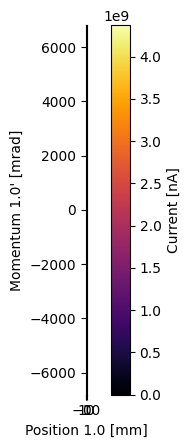

In [74]:
position = x
momentum = xp
I_plot = I * 1e9  # unit nA
theta = np.linspace(0, 2 * np.pi, 100)
E_rms =  e_rms * 1e6  # convert to mm mrad
A = alpha
B = beta
x_e = np.sqrt(4 * E_rms * B) * np.cos(theta)
x_prime_e = -np.sqrt(4 * E_rms / B) * (
    A * np.cos(theta) + np.sin(theta)
)  # parametrisizing the ellipse (Epsilon = 4*Epsilon_rms)
m, n = I_plot.shape
binlength_position = (max(position) - min(position)) / n
binlength_momentum = (max(momentum) - min(momentum)) / m
plt.imshow(
    I_plot,
    cmap="inferno",
    origin="lower",
    extent=(
        min(position) - binlength_position / 2,
        max(position) + binlength_position / 2,
        min(momentum) - binlength_momentum / 2,
        max(momentum) + binlength_momentum / 2,
    ),
)
plt.plot(
    x_e, x_prime_e, "r--", label=r"$\epsilon_{rms}$ = " + f"{round(e_rms, 4)} [mm mrad]"
)
plt.colorbar(label="Current [nA]")
plt.xlabel(f"Position {axis} [mm]")
plt.ylabel(f"Momentum {axis}' [mrad]")
plt.show()

In [65]:
sigma_position_sigma_momentum

np.float64(-1.6183175177305215e-05)